In [26]:
# 의료 기초 데이터 분석 미니 프로젝트
# Numpy + Pandas + Matplotlib

#===========================
# [A] 라이브러리 Import
#===========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#============================
# [B] Pandas 출력 옵션(선택)
#============================

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 200)



In [27]:
#============================
# [1] 데이터 준비
#============================


# 의료(건강검진) 기초 데이터

data = {
    "측정일": [
        "2026-02-01","2026-02-01","2026-02-02","2026-02-02","2026-02-03",
        "2026-02-03","2026-02-04","2026-02-04","2026-02-05","2026-02-05",
        "2026-02-06","2026-02-06","2026-02-07","2026-02-07","2026-02-08"
    ],
    "환자ID": [
        "P001","P002","P003","P004","P005",
        "P006","P007","P008","P009","P010",
        "P011","P012","P013","P014","P015"
    ],
    "성별": ["F","M","M","F","F","M","M","F","F","M","F","M","M","F","F"],
    "나이":  [25, 31, 44, np.nan, 52, 39, 28, 33, 47, 61, 29, 42, np.nan, 36, 55],
    "키":    ["162cm","175cm","168cm","160cm","158cm","180cm","172cm","165cm","170cm","177cm","159cm","174cm","169cm","163cm","157cm"],
    "몸무게": ["54kg","78kg","70kg","52kg","60kg","90kg","68kg","58kg","73kg","82kg","50kg","76kg","71kg","57kg","66kg"],
    "SBP(수축기)": [108, 135, 142, 118, 150, 130, 125, 112, 140, 160, 105, 138, 145, 120, 155],
    "DBP(이완기)": [ 70,  88,  92,  75,  95,  85,  80,  72,  90, 100,  68,  89,  96,  78,  97],
    "심박수":      [72,  84,  90,  68,  95,  78,  70,  75,  88,  92,  66,  80,  86,  73,  89],
    "공복혈당":    [92,  110, 125,  98, 130, np.nan, 105,  90, 118, 140,  88, 112, 128, 100, np.nan],
    "흡연":        ["N","Y","Y","N","N","Y","N","N","Y","Y","N","Y","Y","N","N"],
    "운동빈도(주)": [3, 1, 0, 2, np.nan, 1, 4, 2, 1, 0, 5, 1, 0, 3, np.nan],
}

df = pd.DataFrame(data)



In [28]:
#============================
# [2] 데이터 탐색
#============================

print('============================')
print('  2) 데이터 탐색')
print('============================')

print("\n[head()]")
print(df.head()) 

print("\n[info()]") # 데이터 구조 확인
print(df.info())

print('\n[describe()]') # 숫자 칼럼 요약
num_cols = ['나이', 'SBP(수축기)','DBP(이완기)', '심박수', '공복혈당', '운동빈도(주)']
print(df[num_cols].describe())

  2) 데이터 탐색

[head()]
          측정일  환자ID 성별    나이      키   몸무게  SBP(수축기)  DBP(이완기)  심박수   공복혈당 흡연  운동빈도(주)
0  2026-02-01  P001  F  25.0  162cm  54kg       108        70   72   92.0  N      3.0
1  2026-02-01  P002  M  31.0  175cm  78kg       135        88   84  110.0  Y      1.0
2  2026-02-02  P003  M  44.0  168cm  70kg       142        92   90  125.0  Y      0.0
3  2026-02-02  P004  F   NaN  160cm  52kg       118        75   68   98.0  N      2.0
4  2026-02-03  P005  F  52.0  158cm  60kg       150        95   95  130.0  N      NaN

[info()]
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   측정일       15 non-null     str    
 1   환자ID      15 non-null     str    
 2   성별        15 non-null     str    
 3   나이        13 non-null     float64
 4   키         15 non-null     str    
 5   몸무게       15 non-null     str    
 6   SBP(수축기)  15 non-null     int64  
 7   DBP(

In [29]:
#============================
# [3] 데이터 정제 및 변환
#============================

print('============================')
print(' 3) 데이터 정제 및 변환')
print('============================')


#------------------------------------------
# 3-1) 타입 변환 : 날짜 문자열 => datetime
#------------------------------------------

# '2026-03-05' => object(문자열), 문자열로 데이터 저장하면 안됨
# datetime64로 변화해서 데이터 분석

# pd.to_datetime():문자열을 날짜/시간 타입으로 변환
df['측정일'] = pd.to_datetime(df['측정일'])


#----------------------------------------------
# 3-2) 단위 제거 : '170cm' -> 170, '65kg' -> 65
#----------------------------------------------
# str.replace() : 문자열 치환(여기서는 단위 제거)
# astype(int) : 숫자형으로 변환

df['키_cm'] = df['키'].str.replace('cm', '', regex=False).astype(int)
df['몸무게_kg'] = df['몸무게'].str.replace('kg', '', regex=False).astype(int)

# 원본(키, 몸무게) 컬럼은 '문자열'이라 분석에 불리하므로 
# 보통 숫자형 컬럼(키_cm, 몸무게_kg)만 쓰는 편

print(df)
 

#----------------------------------------------
# 3-3) 결측치 확인
#----------------------------------------------

print('\n[결측치 개수 확인]')
print(df.isnull().sum())


#----------------------------------------------
# 3-4) 결측치 처리(예시)
#----------------------------------------------
'''
결측치 처리 방식은 정답이 1개가 아니라, 상활에 따라 다름
- 나이 : 평균으로 채울
- 공복혈닫 : 중앙값으로 채울(극단값 영향을 줄이고 싶을때)
- 운동빈도 : 0으로 채움(운동기록이 없으면 0으로 가정하는 경우)
'''

df['나이'] = df['나이'].fillna(df['나이'].mean())
df['공복혈당'] = df['공복혈당'].fillna(df['공복혈당'].median())
df['운동빈도(주)'] = df['운동빈도(주)'].fillna(0)


#----------------------------------------------
# 3-5) 파생 컬럼 생성(변환)
#----------------------------------------------
# 기존 컬럼을 이용해서 새로운 컬럼을 만드는 것

# BMI = 몸무게(kg) / 키(m)^2
df['키_m'] = df['키_cm'] / 100
df['BMI'] = df['몸무게_kg'] / (df['키_m'] ** 2)
print(df['BMI'])

# 맥박압(pp) = SBP - DBP (혈관 탄성/압력 차이를 보는 간단한 자료)
df['맥박압_PP'] = df['SBP(수축기)'] - df['DBP(이완기)']
print(df['맥박압_PP'])

# 평균동맥압('MAP) = (SBP + 2*DBP) / 3 (기초적인 참고 자료)
df['평균동맥압_MAP'] = df['SBP(수축기)'] + 2 *df['DBP(이완기)'] / 3
print(df['평균동맥압_MAP'])


#----------------------------------------------
# 3-6) 범주화(카테고리 만들기) : 혈압 단계 분류
#----------------------------------------------

'''
기준(간단 버전)
- 정상 : SBP > 120 그리고 DBP < 80
- 주의(상승) : SBP  120 ~ 129 그리고 DBP < 80
- 고혈압 1기 : SBP  130 ~ 139 그리고 DBP  80 ~ 89
- 고혈압 2기 : SBP >= 140 그리고 DBP >= 90
'''

def bp_category(sbp,dbp) :
    if (sbp < 120) and (dbp < 80):
        return '정상'
    elif (120 <= sbp <= 129) and (dbp < 80):
        return '주의(상승)'
    elif (130 <= sbp <= 139) or ( 80 <= dbp <= 89):
        return '고혈압 1기'
    elif (120<= sbp >= 140) or (dbp >=  90):
        return '고혈압 2기'
    else:
        return'기타'
    
# apply() : 행 단위로 함수를 적용할 때 자주 사용   
# lambda row : 익명 함수(이름 없는 함수)
# lambda 입력값 : 계산식

df['혈압분류'] = df.apply(lambda row: bp_category(row['SBP(수축기)'], row['DBP(이완기)']),axis=1)
print(df['혈압분류'])


df['나이'].apply(lambda x: x+1)


#----------------------------------------------
# 3-7) 범주화 : BMI 단계 분류 (간단 예시)
#----------------------------------------------

'''
BMI 분류
- 저체중 : < 18.5
- 정상 : 18.5 ~ 22.9
- 과체중 : 23.0 ~ 24.9
- 비만 : >25.0
'''

'''
my self solve
def bmi_category(bmi) :
    if (bmi < 18.5):
        return '저체중'
    elif (18.5 <= bmi <= 22.9): 
        return '정상'
    elif (23.0 <= bmi <= 24.9):
        return '과체중'
    else:
        return'비만'
'''

def bmi_category(bmi) :
    if (bmi < 18.5):
        return '저체중'
    elif (bmi < 23.0):
        return '정상'
    elif (bmi < 25.0):
        return '과체중'
    else:
        return'비만'
    

df['BMI분류'] = df['BMI'].apply(bmi_category)
print(df['BMI분류'] )

print('\n[정제/변환 결과 미리보기]')
show_cols = ["측정일","환자ID","성별","나이","키_cm","몸무게_kg","SBP(수축기)","DBP(이완기)","공복혈당","운동빈도(주)","BMI","혈압분류","BMI분류"]
print(df[show_cols].head(10))



 3) 데이터 정제 및 변환
          측정일  환자ID 성별    나이      키   몸무게  SBP(수축기)  DBP(이완기)  심박수   공복혈당 흡연  운동빈도(주)  키_cm  몸무게_kg
0  2026-02-01  P001  F  25.0  162cm  54kg       108        70   72   92.0  N      3.0   162      54
1  2026-02-01  P002  M  31.0  175cm  78kg       135        88   84  110.0  Y      1.0   175      78
2  2026-02-02  P003  M  44.0  168cm  70kg       142        92   90  125.0  Y      0.0   168      70
3  2026-02-02  P004  F   NaN  160cm  52kg       118        75   68   98.0  N      2.0   160      52
4  2026-02-03  P005  F  52.0  158cm  60kg       150        95   95  130.0  N      NaN   158      60
5  2026-02-03  P006  M  39.0  180cm  90kg       130        85   78    NaN  Y      1.0   180      90
6  2026-02-04  P007  M  28.0  172cm  68kg       125        80   70  105.0  N      4.0   172      68
7  2026-02-04  P008  F  33.0  165cm  58kg       112        72   75   90.0  N      2.0   165      58
8  2026-02-05  P009  F  47.0  170cm  73kg       140        90   88  118.0  Y      1.

In [30]:
#============================
# [4] 분석
#============================

print('============================')
print(' 4) 분석')
print('============================')


#-------------------------------------------
# 4-1) 최고/최저 : BMI가 가장 높은/낮은사람
#-------------------------------------------

max_bmi_row = df.loc[df['BMI'].idxmax()] # 최댓값 위치 반환
min_bmi_row = df.loc[df['BMI'].idxmin()] # 최솟값 위치 반환

print('\n[BMI 최고]')
print(max_bmi_row[['환자ID', '성별', '나이', '키_cm', '몸무게_kg', 'BMI', 'BMI분류']])
print('\n[BMI 최저]')
print(min_bmi_row[['환자ID', '성별', '나이', '키_cm', '몸무게_kg', 'BMI', 'BMI분류']])


#-------------------------------------------
# 4-2) 혈압 분류별 평균 지표
#-------------------------------------------
# sort_values  : 정렬
# ascending = False : 내림차순
# ascending = True : 오름차순

bp_group = df.groupby('혈압분류')[['SBP(수축기)', 'DBP(이완기)', '맥박압_PP','평균동맥압_MAP', 'BMI', '공복혈당']].mean().sort_values('SBP(수축기)', ascending=False)
print('\n[혈압 분류별 평균]')
print(bp_group)


#-------------------------------------------
# 4-3) 성별 평균 비교
#-------------------------------------------

gender_mean = df.groupby('성별')[['SBP(수축기)', 'DBP(이완기)', '심박수','공복혈당', 'BMI', '운동빈도(주)']].mean()
print('\n[성별 평균 비교]')
print(gender_mean)


#-------------------------------------------
# 4-4) 나이대(연령대 만들기) + 그룹 평균
#-------------------------------------------

'''
나이대는 분석에서 자주 사용
 - pd.cut() : 숫자를 구간으로 나눠 범부형 컬럼 생성

 (a, b]
왼쪽 제외 오른쪽 포함
(29, 39]
29 < 나이 <=39
'''

bins = [0, 29, 39, 49, 59, 120]
labels =['20대', '30대', '40대', '50대', '60대 이상']
df['나이대'] = pd.cut(df['나이'], bins=bins, labels=labels, right = True)

age_group = df.groupby('나이대')[['SBP(수축기)', 'DBP(이완기)', '공복혈당', 'BMI' ]].mean()
print('\n[나이대별 평균]')   
print(age_group)        


#-------------------------------------------
# 4-5) 상관관계 (수치형 칼럼)
#-------------------------------------------

'''
corr() : 상관계수(-1, 1)
 -  1에 가까울수록 같이 오르는 경향(양의 상관)
 -  -1에 가까울수록 반대로 움직이는 경향(음의 상관)
 -  0에 가까우면 관계가 거의 없음(무상관에 가까움)
'''

corr_cols = ["나이", "키_cm", "몸무게_kg", "SBP(수축기)", "DBP(이완기)", "심박수", "공복혈당", "운동빈도(주)", "BMI", "맥박압_PP", "평균동맥압_MAP"]
corr_df = df[corr_cols].corr()

print('\n[상관관계]')   
print(corr_df)       


#-------------------------------------------
# 4-6) 조건 필터링
#-------------------------------------------

''''
예시 위험군 조건 :
 - 혈압 : 고혈암 2기
 - 공복혈당 : 126이상(당뇨 기준으로 자주 언급되는 구간)
 - BMI : 25이상(비만)
 - 해당 조건 하나라도 TRUE면 관심 대상이라고 가정
'''
 
risk_df =df[
    (df['혈압분류'] == '고혈압2기') |
    (df['공복혈당'] >= 126) |
    (df['BMI'] >= 25.0)  
].copy()

print('\n[관심 대상 목록]')   
print(risk_df[["환자ID", "성별", "나이", "SBP(수축기)", "DBP(이완기)", "혈압분류", "공복혈당", "BMI", "BMI분류", "운동빈도(주)"]])




 4) 분석

[BMI 최고]
환자ID           P006
성별                M
나이             39.0
키_cm            180
몸무게_kg           90
BMI       27.777778
BMI분류            비만
Name: 5, dtype: object

[BMI 최저]
환자ID           P011
성별                F
나이             29.0
키_cm            159
몸무게_kg           50
BMI       19.777699
BMI분류            정상
Name: 10, dtype: object

[혈압 분류별 평균]
          SBP(수축기)  DBP(이완기)     맥박압_PP  평균동맥압_MAP        BMI        공복혈당
혈압분류                                                                     
고혈압 2기  148.666667     95.00  53.666667     212.00  25.317425  125.166667
고혈압 1기  132.000000     85.50  46.500000     189.00  25.333739  109.250000
주의(상승)  120.000000     78.00  42.000000     172.00  21.453574  100.000000
정상      110.750000     71.25  39.500000     158.25  20.492570   92.000000

[성별 평균 비교]
      SBP(수축기)  DBP(이완기)        심박수        공복혈당        BMI  운동빈도(주)
성별                                                                 
F   126.000000    80.625  78.250000  103.

5) 시각화


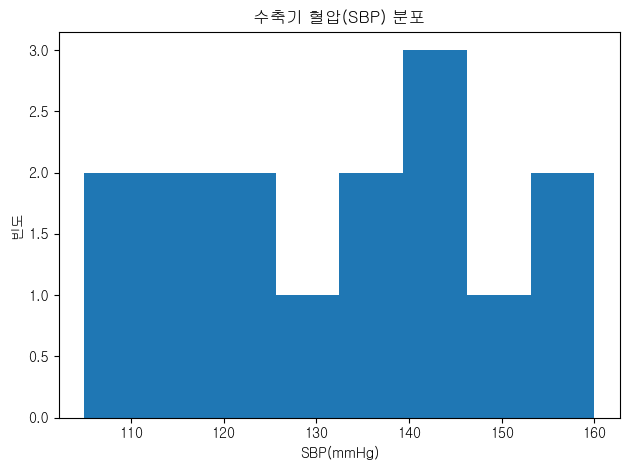

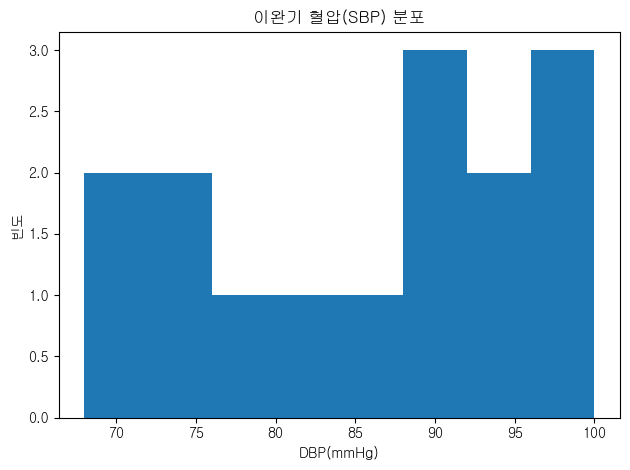

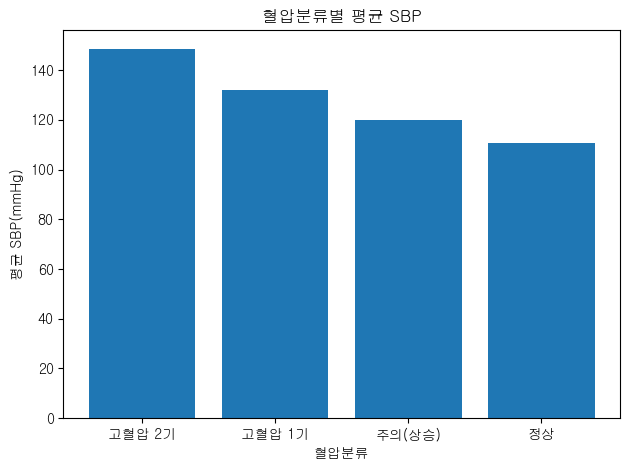

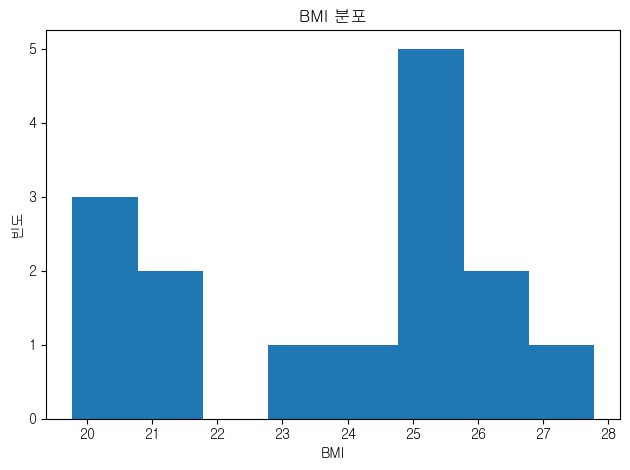

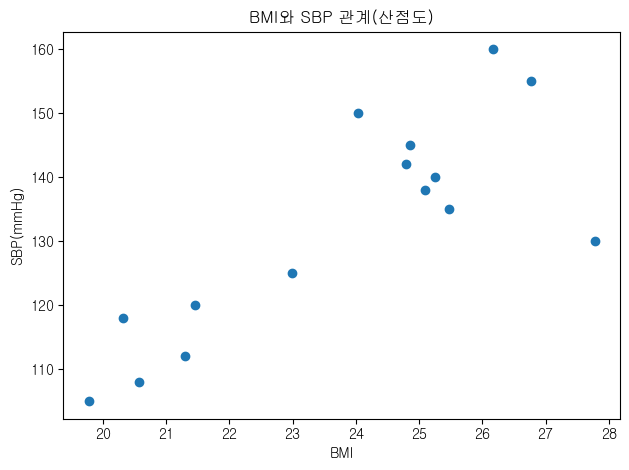

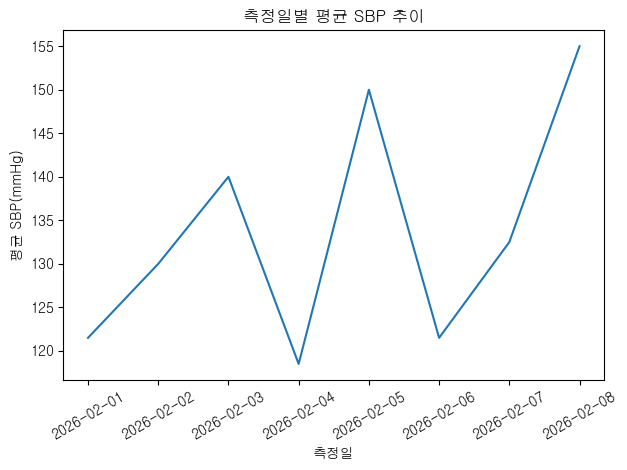

In [41]:
import matplotlib
import matplotlib.font_manager as fm

# 원하는 폰트 파일 경로 문자열로 입력
font_location = "C:\\Windows\\Fonts\\gulim.ttc"

# 지정한 폰트 파일 경로에서 폰트 추출
fontname = fm.FontProperties(fname=font_location).get_name()

# matplotlib의 전역 폰트 설정 변경
matplotlib.rc('font', family=fontname)

# ==============================
# [5] 시각화
# ==============================
print("==============================")
print("5) 시각화")
print("==============================")


# ---------------------------------------------
# 5-1) 혈압(SBP/DBP) 분포 히스토그램
# ---------------------------------------------
'''
히스토그램
- 숫자 데이터가 어느 구간에 얼마나 많이 모여 있는지 보여주는 그래프
- bins가 크면 클 수록 나뉘는 구간이 촘촘함
- 구간 수에 따라 그래프 모양이 달라짐
'''
plt.figure() # 그래프 공간 생성
plt.hist(df["SBP(수축기)"], bins=8) # 구간 설정
plt.title("수축기 혈압(SBP) 분포") # 그래프 위 제목
plt.xlabel("SBP(mmHg)") # 가로축 의미 설명
plt.ylabel("빈도") # 세로축 의미 설명
plt.tight_layout() # 글자가 잘리지 않게 자동 정렬
plt.show() # 그래프 출력

plt.figure()
plt.hist(df["DBP(이완기)"], bins=8)
plt.title("이완기 혈압(SBP) 분포")
plt.xlabel("DBP(mmHg)")
plt.ylabel("빈도")
plt.tight_layout()
plt.show()


# ---------------------------------------------
# 5-2) 혈압분류별 평균 SBP 막대그래프
# ---------------------------------------------
bp_sbp_mean = df.groupby("혈압분류")["SBP(수축기)"].mean().sort_values(ascending=False)

plt.figure()
plt.bar(bp_sbp_mean.index, bp_sbp_mean.values)
plt.title("혈압분류별 평균 SBP")
plt.xlabel("혈압분류")
plt.ylabel("평균 SBP(mmHg)")
plt.tight_layout()
plt.show()


# ---------------------------------------------
# 5-3) BMI 분포 히스토그램
# ---------------------------------------------
plt.figure()
plt.hist(df["BMI"], bins=8)
plt.title("BMI 분포")
plt.xlabel("BMI")
plt.ylabel("빈도")
plt.tight_layout()
plt.show()


# ---------------------------------------------
# 5-4) 산점도 : BMI vs SBP
# ---------------------------------------------
'''
산점도 : 두 개의 숫자 변수 관계를 점(dot)으로 표현 그래프
'''
plt.figure()
plt.scatter(df["BMI"], df["SBP(수축기)"])
plt.title("BMI와 SBP 관계(산점도)")
plt.xlabel("BMI")
plt.ylabel("SBP(mmHg)")
plt.tight_layout()
plt.show()


# ---------------------------------------------
# 5-5) 측정일 기준 SBP 추이(날짜별 평균)
# ---------------------------------------------
date_sbp = df.groupby("측정일")["SBP(수축기)"].mean()

plt.figure()
plt.plot(date_sbp.index, date_sbp.values)
plt.title("측정일별 평균 SBP 추이")
plt.xlabel("측정일")
plt.ylabel("평균 SBP(mmHg)")
plt.xticks(rotation=30) # x축 눈금(ticks) : 글자가 길 때
plt.tight_layout()
plt.show()